<a href="https://colab.research.google.com/github/GoshItsJosh/number_recognition/blob/main/number_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from keras.datasets import mnist

In [8]:
(X_train, y_train),(Xtest, y_test)=mnist.load_data()

In [9]:
print(X_train.shape)

(60000, 28, 28)


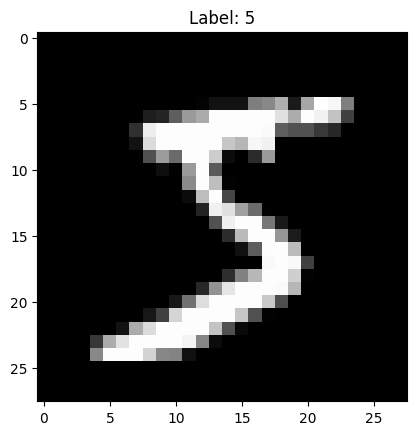

In [10]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [11]:
X_train_normalized = X_train.astype('float32') / 255
Xtest_normalized = Xtest.astype('float32') / 255

model = keras.Sequential([
    layers.Reshape(target_shape=(28, 28, 1), input_shape=(28, 28)), # Reshape for CNN input
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adamw',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\nTraining the model...")
history = model.fit(
    X_train_normalized,
    y_train,
    epochs=12,
    batch_size=32,
    validation_split=0.2
)

print("\nModel training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training the model...
Epoch 1/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9556 - loss: 0.1439 - val_accuracy: 0.9823 - val_loss: 0.0604
Epoch 2/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9851 - val_loss: 0.0501
Epoch 3/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9883 - val_loss: 0.0402
Epoch 4/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9889 - val_loss: 0.0454
Epoch 5/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9937 - loss: 0.0183 - val_accuracy: 0.9896 - val_loss: 0.0366
Epoch 6/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9953 - loss: 0.0136 - val_accuracy: 0.9897 - val_loss: 0.0420
Epoch 7/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9963 - loss: 0.0107 - val_accuracy: 0.9868 - val_loss: 0.0580
Epoch 8/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/st

In [12]:
print("\nEvaluating the model on the test set...")
loss, accuracy = model.evaluate(Xtest_normalized, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating the model on the test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9872 - loss: 0.0486
Test Loss: 0.0486
Test Accuracy: 0.9872


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Found a misclassified image at index: 78


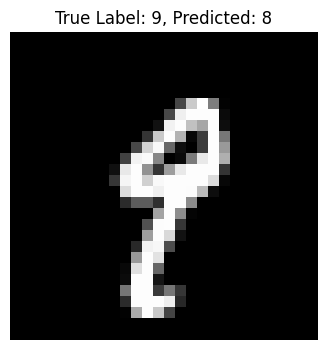

In [13]:
import numpy as np

predictions = model.predict(Xtest_normalized)
predicted_labels = np.argmax(predictions, axis=1)

misclassified_index = None
for i in range(len(y_test)):
    if predicted_labels[i] != y_test[i]:
        misclassified_index = i
        break

if misclassified_index != None:
    print(f"\nFound a misclassified image at index: {misclassified_index}")
    plt.figure(figsize=(4, 4))
    plt.imshow(Xtest[misclassified_index], cmap='gray')
    plt.title(f"True Label: {y_test[misclassified_index]}, Predicted: {predicted_labels[misclassified_index]}")
    plt.axis('off')
    plt.show()
else:
    print("No misclassified images found in the test set.")

In [ ]:
import numpy as np
import tensorflow as tf
import gradio as gr

print(gr.__version__)

def predict_digit(sketch_dict):
    image = sketch_dict["composite"]

    # Explicitly check for None or empty/invalid image data.
    if image is None or (isinstance(image, np.ndarray) and image.size == 0):
        return {str(i): 0.0 for i in range(10)}

    # Ensure image is a TensorFlow tensor before resizing, to catch issues early
    try:
        image = tf.convert_to_tensor(image, dtype=tf.float32)
    except Exception as e:
        print(f"DEBUG: Error converting image to tensor: {e}")
        return {str(i): 0.0 for i in range(10)}

    # After conversion, check if the tensor is still problematic (e.g., empty shape or rank 0)
    if tf.size(image) == 0 or image.shape.rank == 0:
        return {str(i): 0.0 for i in range(10)}

    # Preprocess the image to match the training data format
    # 1. Resize to 28x28
    image = tf.image.resize(image, (28, 28))

    # 2. Convert to grayscale and normalize (assuming input is RGBA/RGB from sketchpad)
    # The sketchpad returns a 4-channel image (RGBA), we need to convert it to grayscale (1 channel)
    if image.shape[-1] == 4: # RGBA
        image = tf.image.rgb_to_grayscale(image[:,:,:3]) # Take only RGB channels, convert to grayscale
    elif image.shape[-1] == 3: # RGB
        image = tf.image.rgb_to_grayscale(image)
    # At this point, image shape is (28, 28, 1)

    # Invert colors: 255 - pixel_value (assuming 0-255 range initially)
    image = tf.cast(image, dtype=tf.float32)
    image = 255.0 - image
    image = image / 255.0  # Normalize to 0-1 range

    # Reshape for the model: (1, 28, 28) - remove channel dim and add batch dim.
    # The model's first layer is Reshape(target_shape=(28, 28, 1), input_shape=(28, 28)).
    # It expects an input of shape (batch_size, 28, 28).
    image = tf.squeeze(image, axis=-1) # image becomes (28, 28)
    image = tf.expand_dims(image, axis=0) # image becomes (1, 28, 28)

    # Make a prediction using the trained model
    predictions = model.predict(image)
    predicted_label = np.argmax(predictions[0])

    # Return the predictions in a format compatible with gr.Label
    # Gradio expects a dictionary where keys are class labels and values are probabilities
    confidences = {str(i): float(predictions[0][i]) for i in range(10)}
    return confidences

interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(type="numpy", label="Draw a single digit (0-9)"),
    outputs=gr.Label(num_top_classes=3, label="Top Predictions"),
    live=True,
    title="MNIST Digit Classifier Board",
    description="Draw a clear number in the box, trying to center it as much as possible."
)

interface.launch(debug=True)

6.20.0
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a0c5011362bfa257ef.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━